# Logistic Regression — Visualizing the PDF's Fruit Example

This notebook visualizes the exact worked example from *Lesson 8 — Logistic Regression*.

**Dataset (is the fruit an apple?):**

| Fruit | Weight $x_1$ (g) | Color score $x_2$ | Apple? $y$ |
|------|------|------|------|
| 1 | 150 | 0.9 | 1 |
| 2 | 180 | 0.8 | 1 |
| 3 | 120 | 0.3 | 0 |
| 4 | 130 | 0.4 | 0 |

**Model:** $\;z = \beta_0 + \beta_1 x_1 + \beta_2 x_2,\qquad \hat{y}=\sigma(z)=\dfrac{1}{1+e^{-z}}$

**Given coefficients:** $\beta_0=-20,\ \beta_1=0.1,\ \beta_2=5$

**New fruit to classify:** $x_1=160,\ x_2=0.85$

[PDF File](https://docs.google.com/document/d/1rb8J1mhDc6QJ1WLATWZYd82QAY6aabiRWzwm-O5Ajm8/edit?tab=t.0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Coefficients given in the PDF
b0, b1, b2 = -20.0, 0.1, 5.0

# Training data: weight, color score, label
X = np.array([[150, 0.9],
              [180, 0.8],
              [120, 0.3],
              [130, 0.4]], dtype=float)
y = np.array([1, 1, 0, 0])

# New fruit from the PDF
new_fruit = np.array([160.0, 0.85])

print("Coefficients:  b0 =", b0, " b1 =", b1, " b2 =", b2)
print("New fruit:     weight =", new_fruit[0], " color score =", new_fruit[1])

Coefficients:  b0 = -20.0  b1 = 0.1  b2 = 5.0
New fruit:     weight = 160.0  color score = 0.85


## Step-by-step prediction for the new fruit

Following the PDF exactly.

**Step 1 — linear combination:**
$$z = -20 + 0.1\cdot 160 + 5\cdot 0.85 = -20 + 16 + 4.25 = 0.25$$

**Step 2 — sigmoid:**
$$\hat{y} = \frac{1}{1+e^{-0.25}} \approx 0.562$$

In [ ]:
x1, x2 = new_fruit
term0 = b0
term1 = b1 * x1
term2 = b2 * x2
z = term0 + term1 + term2
y_hat = sigmoid(z)

print(f"Step 1:  z = {b0} + {b1}*{x1} + {b2}*{x2}")
print(f"           = {term0} + {term1} + {term2}")
print(f"           = {z}")
print(f"Step 2:  y_hat = 1 / (1 + e^(-{z})) = {y_hat:.3f}")
print()
decision = "Apple (1)" if y_hat >= 0.5 else "Not apple (0)"
print(f"Threshold 0.5  ->  classify as: {decision}")

Step 1:  z = -20.0 + 0.1*160.0 + 5.0*0.85
           = -20.0 + 16.0 + 4.25
           = 0.25
Step 2:  y_hat = 1 / (1 + e^(-0.25)) = 0.562

Threshold 0.5  ->  classify as: Apple (1)


## Visualize the example in one frame

Four panels:
1. **Sigmoid curve** with the new fruit's $z=0.25$ mapped to $\hat{y}=0.562$.
2. **Feature space** (weight vs color score): the four fruits, the new fruit, the decision boundary ($z=0$), and the probability surface.
3. **Predicted probability** for every fruit, with the 0.5 threshold.
4. **How $z$ is built** for the new fruit — the contribution of each term.

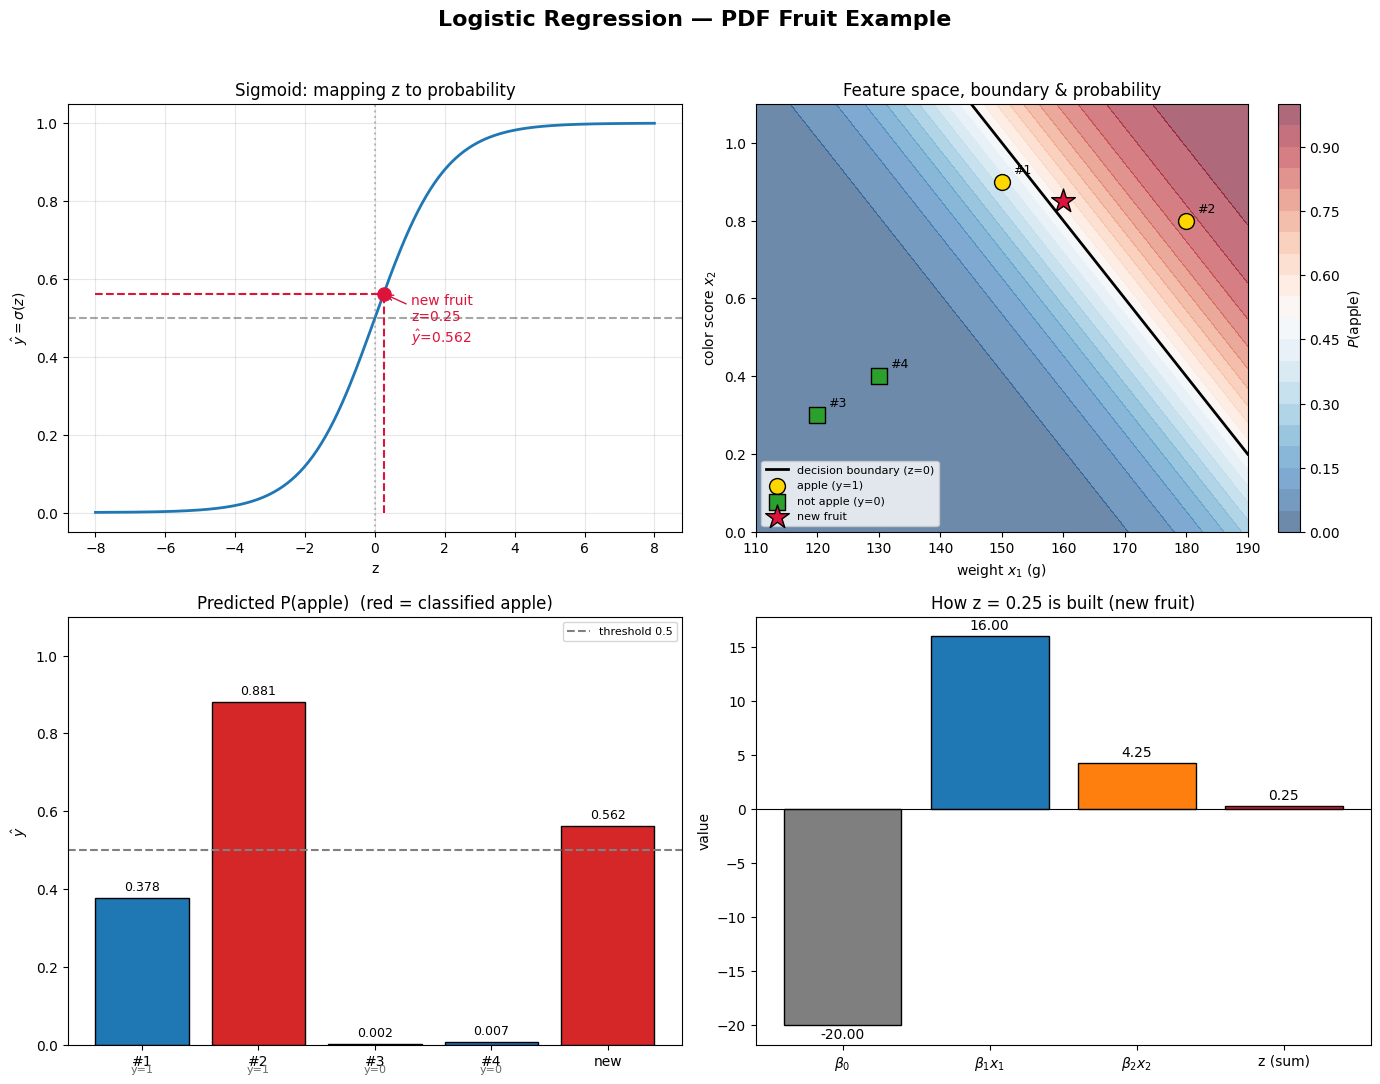

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Logistic Regression — PDF Fruit Example", fontsize=16, fontweight="bold")

# ---------- (1) Sigmoid curve ----------
a = ax[0, 0]
zz = np.linspace(-8, 8, 400)
a.plot(zz, sigmoid(zz), color="tab:blue", lw=2)
a.axhline(0.5, ls="--", color="gray", alpha=0.7)
a.axvline(0, ls=":", color="gray", alpha=0.5)
# mark the new fruit
a.plot([z, z], [0, y_hat], ls="--", color="crimson")
a.plot([-8, z], [y_hat, y_hat], ls="--", color="crimson")
a.scatter([z], [y_hat], color="crimson", s=90, zorder=5)
a.annotate(f"new fruit\nz={z:.2f}\n$\\hat{{y}}$={y_hat:.3f}",
           (z, y_hat), textcoords="offset points", xytext=(20, -35),
           color="crimson", fontsize=10,
           arrowprops=dict(arrowstyle="->", color="crimson"))
a.set_title("Sigmoid: mapping z to probability")
a.set_xlabel("z"); a.set_ylabel(r"$\hat{y}=\sigma(z)$")
a.grid(alpha=0.3)

# ---------- (2) Feature space + decision boundary + probability fill ----------
a = ax[0, 1]
w_grid = np.linspace(110, 190, 200)
c_grid = np.linspace(0.0, 1.1, 200)
WG, CG = np.meshgrid(w_grid, c_grid)
P = sigmoid(b0 + b1 * WG + b2 * CG)
cf = a.contourf(WG, CG, P, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(cf, ax=a, label=r"$P(\mathrm{apple})$")
# decision boundary z = 0  ->  c = (-b0 - b1*w)/b2
boundary_c = (-b0 - b1 * w_grid) / b2
a.plot(w_grid, boundary_c, "k-", lw=2, label="decision boundary (z=0)")
# training points
for cls, marker, lbl in [(1, "o", "apple (y=1)"), (0, "s", "not apple (y=0)")]:
    m = y == cls
    a.scatter(X[m, 0], X[m, 1], marker=marker, s=130, edgecolor="black",
              c=("gold" if cls == 1 else "tab:green"), label=lbl, zorder=5)
for i, (wt, cs) in enumerate(X, 1):
    a.annotate(f"#{i}", (wt, cs), textcoords="offset points", xytext=(8, 6), fontsize=9)
# new fruit
a.scatter([new_fruit[0]], [new_fruit[1]], marker="*", s=320, c="crimson",
          edgecolor="black", label="new fruit", zorder=6)
a.set_xlim(110, 190); a.set_ylim(0, 1.1)
a.set_title("Feature space, boundary & probability")
a.set_xlabel("weight $x_1$ (g)"); a.set_ylabel("color score $x_2$")
a.legend(loc="lower left", fontsize=8)

# ---------- (3) Predicted probability per fruit ----------
a = ax[1, 0]
z_all = b0 + b1 * X[:, 0] + b2 * X[:, 1]
p_all = sigmoid(z_all)
names = [f"#{i}" for i in range(1, 5)] + ["new"]
probs = list(p_all) + [y_hat]
bar_colors = ["tab:red" if p >= 0.5 else "tab:blue" for p in probs]
bars = a.bar(names, probs, color=bar_colors, edgecolor="black")
a.axhline(0.5, ls="--", color="gray", label="threshold 0.5")
for bar, p in zip(bars, probs):
    a.text(bar.get_x() + bar.get_width() / 2, p + 0.02, f"{p:.3f}",
           ha="center", fontsize=9)
# mark true labels for training fruits
for i, (cls) in enumerate(y):
    a.text(i, -0.07, f"y={cls}", ha="center", fontsize=8, color="dimgray")
a.set_ylim(0, 1.1)
a.set_title("Predicted P(apple)  (red = classified apple)")
a.set_ylabel(r"$\hat{y}$"); a.legend(fontsize=8)

# ---------- (4) Building z for the new fruit ----------
a = ax[1, 1]
labels = [r"$\beta_0$", r"$\beta_1 x_1$", r"$\beta_2 x_2$", "z (sum)"]
vals = [term0, term1, term2, z]
colors = ["tab:gray", "tab:blue", "tab:orange", "crimson"]
b = a.bar(labels, vals, color=colors, edgecolor="black")
for bar, v in zip(b, vals):
    a.text(bar.get_x() + bar.get_width() / 2,
           v + (0.6 if v >= 0 else -1.2), f"{v:.2f}", ha="center", fontsize=10)
a.axhline(0, color="black", lw=0.8)
a.set_title("How z = 0.25 is built (new fruit)")
a.set_ylabel("value")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Reading the result

- The new fruit lands at $z = 0.25$, just above zero, so the sigmoid maps it to $\hat{y} \approx 0.562$. Since $0.562 > 0.5$, it is classified as **Apple (1)** — matching the PDF.
- In the feature-space panel it sits just on the apple (red) side of the decision boundary.
- A note worth seeing: with these *illustrative* coefficients, training fruit **#1** (150 g, 0.9) gets probability ≈ 0.378 and would be predicted *not apple*, even though its true label is apple. So these coefficients are a teaching example, not a fitted model — they show how prediction works, not a perfect fit.

## Optional: what a *fitted* model looks like

For contrast, fit logistic regression to the four points and compare its boundary
to the PDF's hand-picked coefficients. (Features are scaled because weight and
color score are on very different ranges.)

Fitted model probability for the new fruit: 0.989
Training accuracy: 1.0


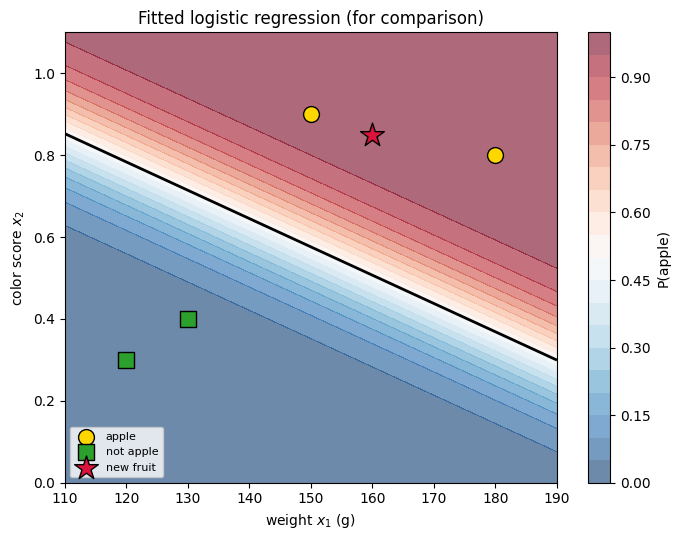

In [ ]:
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)
    clf = LogisticRegression(C=100).fit(Xs, y)

    new_s = scaler.transform(new_fruit.reshape(1, -1))
    p_fit = clf.predict_proba(new_s)[0, 1]
    print(f"Fitted model probability for the new fruit: {p_fit:.3f}")
    print("Training accuracy:", clf.score(Xs, y))

    fig, a = plt.subplots(figsize=(7, 5.5))
    WG, CG = np.meshgrid(np.linspace(110, 190, 200), np.linspace(0, 1.1, 200))
    grid = np.c_[WG.ravel(), CG.ravel()]
    Pf = clf.predict_proba(scaler.transform(grid))[:, 1].reshape(WG.shape)
    cf = a.contourf(WG, CG, Pf, levels=20, cmap="RdBu_r", alpha=0.6)
    plt.colorbar(cf, ax=a, label="P(apple)")
    a.contour(WG, CG, Pf, levels=[0.5], colors="black", linewidths=2)
    for cls, marker, c, lbl in [(1, "o", "gold", "apple"), (0, "s", "tab:green", "not apple")]:
        m = y == cls
        a.scatter(X[m, 0], X[m, 1], marker=marker, s=130, c=c, edgecolor="black", label=lbl, zorder=5)
    a.scatter([new_fruit[0]], [new_fruit[1]], marker="*", s=320, c="crimson", edgecolor="black", label="new fruit", zorder=6)
    a.set_title("Fitted logistic regression (for comparison)")
    a.set_xlabel("weight $x_1$ (g)"); a.set_ylabel("color score $x_2$")
    a.legend(loc="lower left", fontsize=8)
    plt.tight_layout(); plt.show()
except ImportError:
    print("scikit-learn not available — skipping the fitted-model comparison.")